# Interactive Demo - Lexical Semantic Embedding Model

Welcome to the interactive demonstration of our Lexical Semantic Embedding Model! This notebook provides hands-on examples and interactive widgets to explore the model's capabilities.

## Table of Contents
1. [Quick Start Demo](#Quick-Start-Demo)
2. [Interactive Similarity Testing](#Interactive-Similarity-Testing)
3. [Semantic Search Examples](#Semantic-Search-Examples)
4. [Embedding Exploration](#Embedding-Exploration)
5. [Real-time Inference](#Real-time-Inference)
6. [Use Case Examples](#Use-Case-Examples)
7. [Performance Showcase](#Performance-Showcase)

In [ ]:
# Setup environment for demo
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath(".."))
# Add project root to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

# Import required libraries
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import time
from datetime import datetime

# Import project modules
from lexical_embedding_model import LexicalSemanticEmbeddingModel
from config.model_config import ModelConfig
from config.data_config import DataConfig
from scripts.evaluate import ModelEvaluator
from scripts.utils import setup_logging, get_device

# Setup
device = get_device()
print(f"🚀 Demo Environment Ready!")
print(f"📱 Device: {device}")
print(f"📁 Project Root: {PROJECT_ROOT}")
print(f"⏰ Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

## Quick Start Demo

Let's start with a quick demonstration of the model's basic capabilities.

In [ ]:
# Load or create demo model
model_config = ModelConfig(model_name="medium")
data_config = DataConfig()

MODEL_PATH = PROJECT_ROOT / "models" / "best_model.pt"

if MODEL_PATH.exists():
    print("📦 Loading trained model...")
    model = LexicalSemanticEmbeddingModel.load_model(MODEL_PATH, device)
    print("✅ Model loaded successfully!")
else:
    print("🔧 Creating demo model...")
    model = LexicalSemanticEmbeddingModel(model_config)
    model = model.to(device)
    print("✅ Demo model created!")

# Create evaluator for easy inference
evaluator = ModelEvaluator(model, data_config, device, batch_size=1)

# Model info
total_params = sum(p.numel() for p in model.parameters())
print(f"\n📊 Model Statistics:")
print(f"   Parameters: {total_params:,}")
print(f"   Architecture: BiLSTM + Multi-Head Attention")
print(f"   Similarity Functions: {', '.join(model_config.similarity_functions)}")

In [ ]:
# Quick demonstration with predefined examples
demo_examples = [
    {
        'sentence1': "The cat sat on the mat.",
        'sentence2': "A feline rested on the rug.",
        'expected': "High Similarity",
        'description': "Synonymous expressions"
    },
    {
        'sentence1': "The weather is beautiful today.",
        'sentence2': "It's a lovely day outside.",
        'expected': "High Similarity",
        'description': "Paraphrased meanings"
    },
    {
        'sentence1': "I love eating pizza.",
        'sentence2': "Pizza is my favorite food.",
        'expected': "Medium Similarity",
        'description': "Related but different structure"
    },
    {
        'sentence1': "The dog is running.",
        'sentence2': "Quantum physics is complex.",
        'expected': "Low Similarity",
        'description': "Completely unrelated topics"
    }
]

print("🎯 QUICK DEMO - Semantic Similarity Examples")
print("=" * 60)

results = []

for i, example in enumerate(demo_examples, 1):
    print(f"\n{i}. {example['description']}")
    print(f"   Sentence 1: '{example['sentence1']}'")
    print(f"   Sentence 2: '{example['sentence2']}'")
    print(f"   Expected: {example['expected']}")
    
    # Get model prediction
    similarities = evaluator.compute_embedding_similarities(
        [example['sentence2']], example['sentence1']
    )
    
    similarity_score = similarities[0][1]
    
    # Interpret score
    if similarity_score > 0.7:
        prediction = "High Similarity"
        color = "🟢"
    elif similarity_score > 0.4:
        prediction = "Medium Similarity"
        color = "🟡"
    else:
        prediction = "Low Similarity"
        color = "🔴"
    
    print(f"   Model Prediction: {color} {prediction} (Score: {similarity_score:.4f})")
    
    results.append({
        'Example': i,
        'Description': example['description'],
        'Expected': example['expected'],
        'Predicted': prediction,
        'Score': similarity_score,
        'Match': '✅' if prediction == example['expected'] else '❌'
    })

# Summary table
results_df = pd.DataFrame(results)
print(f"\n📊 DEMO RESULTS SUMMARY:")
print(results_df.to_string(index=False))

accuracy = (results_df['Match'] == '✅').sum() / len(results_df)
print(f"\n🎯 Demo Accuracy: {accuracy:.1%}")

## Interactive Similarity Testing

Use the widgets below to test the model with your own sentence pairs!

In [ ]:
# Create interactive widgets for testing
def create_similarity_tester():
    # Input widgets
    sentence1_widget = widgets.Textarea(
        value="The cat sat on the mat.",
        placeholder="Enter first sentence...",
        description="Sentence 1:",
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='100%', height='60px')
    )
    
    sentence2_widget = widgets.Textarea(
        value="A feline rested on the rug.",
        placeholder="Enter second sentence...",
        description="Sentence 2:",
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='100%', height='60px')
    )
    
    test_button = widgets.Button(
        description="🔍 Test Similarity",
        button_style='info',
        layout=widgets.Layout(width='200px', height='40px')
    )
    
    output_widget = widgets.Output()
    
    def test_similarity(b):
        with output_widget:
            clear_output(wait=True)
            
            if not sentence1_widget.value.strip() or not sentence2_widget.value.strip():
                print("❌ Please enter both sentences.")
                return
            
            print("🔄 Computing similarity...")
            
            try:
                # Get similarity
                start_time = time.time()
                similarities = evaluator.compute_embedding_similarities(
                    [sentence2_widget.value], sentence1_widget.value
                )
                end_time = time.time()
                
                similarity_score = similarities[0][1]
                
                # Clear and show results
                clear_output(wait=True)
                
                print("📊 SIMILARITY ANALYSIS RESULTS")
                print("=" * 40)
                print(f"Sentence 1: {sentence1_widget.value}")
                print(f"Sentence 2: {sentence2_widget.value}")
                print(f"\n🎯 Similarity Score: {similarity_score:.4f}")
                
                # Interpretation
                if similarity_score > 0.8:
                    interpretation = "🟢 Very High Similarity - Nearly identical meaning"
                elif similarity_score > 0.6:
                    interpretation = "🟢 High Similarity - Very similar meaning"
                elif similarity_score > 0.4:
                    interpretation = "🟡 Medium Similarity - Somewhat related"
                elif similarity_score > 0.2:
                    interpretation = "🟠 Low Similarity - Slightly related"
                else:
                    interpretation = "🔴 Very Low Similarity - Unrelated"
                
                print(f"\n📝 Interpretation: {interpretation}")
                print(f"⏱️ Computation Time: {(end_time - start_time)*1000:.2f} ms")
                
                # Visual indicator
                progress_bar = "█" * int(similarity_score * 20) + "░" * (20 - int(similarity_score * 20))
                print(f"\n📊 Visual Score: [{progress_bar}] {similarity_score:.1%}")
                
            except Exception as e:
                clear_output(wait=True)
                print(f"❌ Error: {str(e)}")
    
    test_button.on_click(test_similarity)
    
    # Layout
    ui = widgets.VBox([
        widgets.HTML("<h3>🧪 Interactive Similarity Tester</h3>"),
        sentence1_widget,
        sentence2_widget,
        test_button,
        output_widget
    ])
    
    return ui

# Display the interactive tester
similarity_tester = create_similarity_tester()
display(similarity_tester)

## Semantic Search Examples

Explore how the model can be used for semantic search and document retrieval.

In [ ]:
# Semantic search demonstration
document_corpus = [
    "Machine learning is a subset of artificial intelligence that focuses on algorithms.",
    "Deep learning uses neural networks with multiple layers to process information.",
    "Natural language processing enables computers to understand human language.",
    "Computer vision allows machines to interpret and analyze visual information.",
    "The weather today is sunny with a temperature of 75 degrees Fahrenheit.",
    "Cooking pasta requires boiling water and adding salt for better flavor.",
    "Exercise is important for maintaining good physical and mental health.",
    "Reading books can improve vocabulary and cognitive abilities significantly.",
    "Traveling to new places broadens perspective and creates lasting memories.",
    "Music has the power to evoke emotions and bring people together.",
    "Photography captures moments in time and preserves them for the future.",
    "Gardening is a relaxing hobby that connects people with nature.",
    "Scientific research advances our understanding of the natural world.",
    "Technology continues to evolve rapidly, changing how we live and work.",
    "Education plays a crucial role in personal and societal development."
]

def perform_semantic_search(query, top_k=5):
    """Perform semantic search on the document corpus."""
    print(f"🔍 SEMANTIC SEARCH RESULTS")
    print(f"Query: '{query}'")
    print("=" * 60)
    
    # Get similarities
    similarities = evaluator.compute_embedding_similarities(document_corpus, query)
    
    # Display results
    for i, (document, score) in enumerate(similarities[:top_k], 1):
        # Visual score representation
        stars = "⭐" * int(score * 5)
        print(f"\n{i}. Score: {score:.4f} {stars}")
        print(f"   Document: {document}")
    
    return similarities[:top_k]

# Test different types of queries
test_queries = [
    "artificial intelligence and algorithms",
    "sunny weather and temperature",
    "learning and education",
    "creative activities and hobbies"
]

for query in test_queries:
    results = perform_semantic_search(query, top_k=3)
    print("\n" + "-" * 80 + "\n")

In [ ]:
# Interactive semantic search widget
def create_search_widget():
    query_widget = widgets.Text(
        value="machine learning algorithms",
        placeholder="Enter your search query...",
        description="Search Query:",
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='100%')
    )
    
    top_k_widget = widgets.IntSlider(
        value=5,
        min=1,
        max=10,
        step=1,
        description="Top Results:",
        style={'description_width': 'initial'}
    )
    
    search_button = widgets.Button(
        description="🔍 Search",
        button_style='success',
        layout=widgets.Layout(width='150px')
    )
    
    output_widget = widgets.Output()
    
    def search_documents(b):
        with output_widget:
            clear_output(wait=True)
            
            if not query_widget.value.strip():
                print("❌ Please enter a search query.")
                return
            
            print("🔄 Searching documents...")
            
            try:
                start_time = time.time()
                similarities = evaluator.compute_embedding_similarities(
                    document_corpus, query_widget.value
                )
                end_time = time.time()
                
                clear_output(wait=True)
                
                print(f"🔍 SEARCH RESULTS for: '{query_widget.value}'")
                print(f"📊 Found {len(document_corpus)} documents in {(end_time - start_time)*1000:.2f} ms")
                print("=" * 70)
                
                for i, (document, score) in enumerate(similarities[:top_k_widget.value], 1):
                    # Score visualization
                    bar_length = int(score * 20)
                    bar = "█" * bar_length + "░" * (20 - bar_length)
                    
                    print(f"\n{i:2d}. [{bar}] {score:.4f}")
                    print(f"     {document}")
                
                # Statistics
                scores = [sim[1] for sim in similarities]
                print(f"\n📈 Score Statistics:")
                print(f"   Highest: {max(scores):.4f}")
                print(f"   Average: {np.mean(scores):.4f}")
                print(f"   Lowest: {min(scores):.4f}")
                
            except Exception as e:
                clear_output(wait=True)
                print(f"❌ Error during search: {str(e)}")
    
    search_button.on_click(search_documents)
    
    ui = widgets.VBox([
        widgets.HTML("<h3>🔍 Interactive Semantic Search</h3>"),
        widgets.HTML(f"<p><i>Search through {len(document_corpus)} documents in our corpus</i></p>"),
        query_widget,
        top_k_widget,
        search_button,
        output_widget
    ])
    
    return ui

# Display the search widget
search_widget = create_search_widget()
display(search_widget)

## Embedding Space Exploration

Visualize how sentences are represented in the embedding space.

In [ ]:
# Embedding space visualization
sample_sentences = [
    "Machine learning is powerful",
    "AI algorithms are effective",
    "Deep learning uses neural networks",
    "The weather is sunny today",
    "It's a beautiful day outside",
    "Temperature is quite warm",
    "I love cooking pasta",
    "Making dinner is enjoyable",
    "Food preparation takes time",
    "Exercise keeps you healthy",
    "Working out is beneficial",
    "Physical activity is important"
]

# Categories for coloring
categories = [
    "AI/ML", "AI/ML", "AI/ML",
    "Weather", "Weather", "Weather",
    "Food", "Food", "Food",
    "Health", "Health", "Health"
]

print("🎨 Creating embedding visualization...")

try:
    # Analyze embeddings using PCA
    embedding_analysis = evaluator.analyze_embeddings(
        sentences=sample_sentences,
        labels=categories,
        method="pca"
    )
    
    if embedding_analysis and 'coordinates' in embedding_analysis:
        coordinates = embedding_analysis['coordinates']
        
        # Create interactive visualization
        fig = go.Figure()
        
        # Color map for categories
        color_map = {
            "AI/ML": "red",
            "Weather": "blue", 
            "Food": "green",
            "Health": "orange"
        }
        
        for category in set(categories):
            # Get points for this category
            category_indices = [i for i, cat in enumerate(categories) if cat == category]
            category_coords = coordinates[category_indices]
            category_sentences = [sample_sentences[i] for i in category_indices]
            
            fig.add_trace(
                go.Scatter(
                    x=category_coords[:, 0],
                    y=category_coords[:, 1],
                    mode='markers+text',
                    marker=dict(
                        size=12,
                        color=color_map[category],
                        opacity=0.7,
                        line=dict(width=2, color='white')
                    ),
                    text=[f"{cat[:2]}{i+1}" for i, cat in enumerate(category_sentences)],
                    textposition="middle center",
                    name=category,
                    hovertext=[f"{category}: {sent}" for sent in category_sentences],
                    hovertemplate='%{hovertext}<extra></extra>'
                )
            )
        
        fig.update_layout(
            title="Sentence Embeddings in 2D Space (PCA Projection)",
            xaxis_title="First Principal Component",
            yaxis_title="Second Principal Component",
            width=800,
            height=600,
            showlegend=True
        )
        
        fig.show()
        
        # Print variance explained
        if 'variance_explained' in embedding_analysis and embedding_analysis['variance_explained'] is not None:
            var_exp = embedding_analysis['variance_explained']
            print(f"\n📊 PCA Analysis:")
            print(f"   PC1 explains {var_exp[0]:.1%} of variance")
            print(f"   PC2 explains {var_exp[1]:.1%} of variance")
            print(f"   Total explained: {sum(var_exp):.1%}")
        
        # Show sentence mapping
        print(f"\n📝 Sentence Mapping:")
        for i, (sentence, category) in enumerate(zip(sample_sentences, categories)):
            print(f"   {category[:2]}{i+1}: {sentence}")
    
    else:
        print("❌ Could not create embedding visualization (sklearn not available)")
        
        # Fallback: similarity matrix heatmap
        print("🔄 Creating similarity matrix instead...")
        
        similarity_matrix = np.zeros((len(sample_sentences), len(sample_sentences)))
        
        for i, sent1 in enumerate(sample_sentences):
            for j, sent2 in enumerate(sample_sentences):
                if i <= j:  # Only compute upper triangle
                    if i == j:
                        similarity_matrix[i, j] = 1.0
                    else:
                        similarities = evaluator.compute_embedding_similarities([sent2], sent1)
                        similarity_matrix[i, j] = similarities[0][1]
                        similarity_matrix[j, i] = similarities[0][1]  # Symmetric
        
        # Create heatmap
        fig, ax = plt.subplots(figsize=(12, 10))
        
        # Truncate sentence labels for readability
        short_labels = [sent[:30] + "..." if len(sent) > 30 else sent for sent in sample_sentences]
        
        sns.heatmap(
            similarity_matrix,
            annot=True,
            fmt='.3f',
            cmap='viridis',
            xticklabels=short_labels,
            yticklabels=short_labels,
            ax=ax,
            cbar_kws={'label': 'Similarity Score'}
        )
        
        ax.set_title('Sentence Similarity Matrix')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
except Exception as e:
    print(f"❌ Error creating visualization: {str(e)}")

## Real-time Inference Performance

Demonstrate the model's inference speed and efficiency.

In [ ]:
# Performance benchmarking
def benchmark_inference():
    print("⚡ PERFORMANCE BENCHMARK")
    print("=" * 40)
    
    # Test sentences of different lengths
    test_cases = [
        {
            'name': 'Short sentences',
            'sent1': 'Hello world',
            'sent2': 'Hi there'
        },
        {
            'name': 'Medium sentences',
            'sent1': 'The quick brown fox jumps over the lazy dog',
            'sent2': 'A fast brown fox leaps above the sleepy canine'
        },
        {
            'name': 'Long sentences',
            'sent1': 'Machine learning and artificial intelligence have revolutionized the way we process information and make decisions in complex systems',
            'sent2': 'AI and ML technologies have transformed how we analyze data and create intelligent solutions for complicated problems'
        }
    ]
    
    results = []
    
    for test_case in test_cases:
        times = []
        
        # Warm up
        for _ in range(3):
            evaluator.compute_embedding_similarities([test_case['sent2']], test_case['sent1'])
        
        # Actual timing
        for _ in range(10):
            start_time = time.time()
            similarities = evaluator.compute_embedding_similarities([test_case['sent2']], test_case['sent1'])
            end_time = time.time()
            times.append((end_time - start_time) * 1000)  # Convert to ms
        
        avg_time = np.mean(times)
        std_time = np.std(times)
        score = similarities[0][1]
        
        results.append({
            'Test Case': test_case['name'],
            'Avg Time (ms)': f"{avg_time:.2f} ± {std_time:.2f}",
            'Similarity Score': f"{score:.4f}",
            'Sent1 Length': len(test_case['sent1']),
            'Sent2 Length': len(test_case['sent2'])
        })
        
        print(f"\n{test_case['name']}:")
        print(f"   Average time: {avg_time:.2f} ± {std_time:.2f} ms")
        print(f"   Similarity: {score:.4f}")
        print(f"   Sentence lengths: {len(test_case['sent1'])}, {len(test_case['sent2'])} chars")
    
    # Summary table
    results_df = pd.DataFrame(results)
    print(f"\n📊 PERFORMANCE SUMMARY:")
    print(results_df.to_string(index=False))
    
    # Model specifications
    print(f"\n🔧 MODEL SPECIFICATIONS:")
    print(f"   Device: {device}")
    print(f"   Parameters: {total_params:,}")
    print(f"   Architecture: BiLSTM + Multi-Head Attention")
    print(f"   Batch Size: {evaluator.batch_size}")
    
    return results

# Run benchmark
benchmark_results = benchmark_inference()

# Use case demonstrations
use_cases = {
    "📧 Customer Support - FAQ Matching": {
        "description": "Automatically match customer queries to relevant FAQ entries",
        "query": "My order hasn't arrived yet and I'm worried about the delivery",
        "documents": [
            "How to track your order and check delivery status",
            "What to do if your package is delayed or missing",
            "Return and refund policy for unsatisfied customers",
            "How to contact customer service for urgent issues",
            "Product warranty information and coverage details"
        ]
    },
    
    "📚 Academic Paper Search": {
        "description": "Find relevant research papers based on topic queries",
        "query": "neural networks for natural language understanding",
        "documents": [
            "Deep Learning Approaches for Text Classification and Sentiment Analysis",
            "Transformer Models and Their Applications in Machine Translation",
            "Convolutional Neural Networks for Image Recognition Tasks",
            "Recurrent Neural Networks for Sequential Data Processing",
            "Attention Mechanisms in Natural Language Processing Systems"
        ]
    },
    
    "💼 Job Matching Platform": {
        "description": "Match job seekers with relevant job postings",
        "query": "experienced software developer with Python and machine learning skills",
        "documents": [
            "Senior Python Developer needed for AI startup with ML experience",
            "Frontend Web Developer position using React and JavaScript",
            "Data Scientist role requiring Python, TensorFlow, and statistics",
            "DevOps Engineer position for cloud infrastructure management",
            "Machine Learning Engineer for computer vision applications"
        ]
    },
    
    "🛒 E-commerce Product Search": {
        "description": "Help customers find products using natural language queries",
        "query": "comfortable running shoes for daily exercise and jogging",
        "documents": [
            "Lightweight athletic sneakers perfect for daily workouts",
            "Professional dress shoes for business and formal occasions",
            "Waterproof hiking boots designed for outdoor adventures",
            "Cushioned running shoes with excellent shock absorption",
            "Casual canvas shoes for everyday wear and comfort"
        ]
    }
}

print("🌟 REAL-WORLD USE CASE DEMONSTRATIONS")
print("=" * 60)

for use_case_name, use_case_data in use_cases.items():
    print(f"\n{use_case_name}")
    print(f"Description: {use_case_data['description']}")
    print(f"\nQuery: '{use_case_data['query']}'")
    print("\nTop Matches:")
    
    # Get similarities
    similarities = evaluator.compute_embedding_similarities(
        use_case_data['documents'], use_case_data['query']
    )
    
    # Display top 3 results
    for i, (document, score) in enumerate(similarities[:3], 1):
        relevance = "🟢 High" if score > 0.6 else "🟡 Medium" if score > 0.3 else "🔴 Low"
        print(f"   {i}. [{score:.4f}] {relevance} - {document}")
    
    print("-" * 60)

print("\n✨ These examples show how the model can be integrated into various applications")
print("   to provide intelligent matching and search capabilities!")

In [ ]:
# Custom use case testing widget
def create_use_case_tester():
    query_widget = widgets.Textarea(
        value="",
        placeholder="Enter your query here...",
        description="Query:",
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='100%', height='60px')
    )
    
    documents_widget = widgets.Textarea(
        value="",
        placeholder="Enter documents/options, one per line...",
        description="Documents:",
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='100%', height='120px')
    )
    
    test_button = widgets.Button(
        description="🔍 Test Use Case",
        button_style='primary',
        layout=widgets.Layout(width='200px')
    )
    
    output_widget = widgets.Output()
    
    def test_use_case(b):
        with output_widget:
            clear_output(wait=True)
            
            if not query_widget.value.strip() or not documents_widget.value.strip():
                print("❌ Please provide both a query and documents.")
                return
            
            # Parse documents
            documents = [doc.strip() for doc in documents_widget.value.split('\n') if doc.strip()]
            
            if len(documents) == 0:
                print("❌ Please provide at least one document.")
                return
            
            print("🔄 Processing your custom use case...")
            
            try:
                start_time = time.time()
                similarities = evaluator.compute_embedding_similarities(
                    documents, query_widget.value
                )
                end_time = time.time()
                
                clear_output(wait=True)
                
                print(f"🎯 CUSTOM USE CASE RESULTS")
                print(f"Query: '{query_widget.value}'")
                print(f"Documents analyzed: {len(documents)}")
                print(f"Processing time: {(end_time - start_time)*1000:.2f} ms")
                print("=" * 50)
                
                # Display all results with rankings
                for i, (document, score) in enumerate(similarities, 1):
                    # Relevance indicator
                    if score > 0.7:
                        relevance = "🟢 Excellent Match"
                    elif score > 0.5:
                        relevance = "🟢 Good Match"
                    elif score > 0.3:
                        relevance = "🟡 Fair Match"
                    else:
                        relevance = "🔴 Poor Match"
                    
                    # Progress bar
                    bar_length = int(score * 20)
                    bar = "█" * bar_length + "░" * (20 - bar_length)
                    
                    print(f"\n{i:2d}. [{bar}] {score:.4f}")
                    print(f"     {relevance}")
                    print(f"     {document}")
                
                # Summary statistics
                scores = [sim[1] for sim in similarities]
                print(f"\n📊 Summary Statistics:")
                print(f"   Best match: {max(scores):.4f}")
                print(f"   Average similarity: {np.mean(scores):.4f}")
                print(f"   Worst match: {min(scores):.4f}")
                
                excellent_matches = sum(1 for score in scores if score > 0.7)
                good_matches = sum(1 for score in scores if 0.5 < score <= 0.7)
                
                print(f"\n🎯 Match Quality:")
                print(f"   Excellent matches: {excellent_matches}/{len(scores)}")
                print(f"   Good matches: {good_matches}/{len(scores)}")
                
            except Exception as e:
                clear_output(wait=True)
                print(f"❌ Error processing use case: {str(e)}")
    
    test_button.on_click(test_use_case)
    
    ui = widgets.VBox([
        widgets.HTML("<h3>🛠️ Custom Use Case Tester</h3>"),
        widgets.HTML("<p><i>Test your own queries and documents to see how the model performs</i></p>"),
        query_widget,
        documents_widget,
        test_button,
        output_widget
    ])
    
    return ui

# Display the custom use case tester
use_case_tester = create_use_case_tester()
display(use_case_tester)

## Demo Summary and Next Steps

Thank you for exploring our Lexical Semantic Embedding Model demo!

In [ ]:
# Demo summary and capabilities overview
print("🎉 DEMO SUMMARY - Lexical Semantic Embedding Model")
print("=" * 60)

capabilities = [
    "✅ Semantic Similarity Computation",
    "✅ Interactive Text Comparison", 
    "✅ Semantic Search and Document Retrieval",
    "✅ Embedding Space Visualization",
    "✅ Real-time Inference Performance",
    "✅ Multiple Use Case Applications",
    "✅ Custom Query Testing"
]

technical_features = [
    "🔧 BiLSTM + Multi-Head Attention Architecture",
    "🔧 Multiple Similarity Functions (cosine, euclidean, manhattan, learned)",
    "🔧 Configurable Model Sizes (small, medium, large, BERT-like)",
    "🔧 GPU/CPU Compatibility",
    "🔧 Production-Ready Implementation",
    "🔧 Comprehensive Evaluation Suite",
    "🔧 Docker Deployment Support"
]

applications = [
    "📧 Customer Support Automation",
    "📚 Academic Research Assistance", 
    "💼 Job Matching Platforms",
    "🛒 E-commerce Product Search",
    "📰 Content Recommendation",
    "🔍 Information Retrieval Systems",
    "🤖 Chatbot Intent Recognition"
]

print("\n🚀 DEMONSTRATED CAPABILITIES:")
for capability in capabilities:
    print(f"   {capability}")

print("\n⚙️ TECHNICAL FEATURES:")
for feature in technical_features:
    print(f"   {feature}")

print("\n🌟 POTENTIAL APPLICATIONS:")
for application in applications:
    print(f"   {application}")

print("\n📊 MODEL SPECIFICATIONS:")
print(f"   🔢 Parameters: {total_params:,}")
print(f"   💻 Device: {device}")
print(f"   🏗️ Architecture: {model_config.model_name}")
print(f"   📏 Hidden Size: {model_config.hidden_size}")
print(f"   🔄 LSTM Layers: {model_config.num_lstm_layers}")
print(f"   🎯 Attention Heads: {model_config.num_attention_heads}")

print("\n🎯 NEXT STEPS:")
next_steps = [
    "1. 📚 Train the model on your specific dataset",
    "2. 🔧 Fine-tune hyperparameters for your use case", 
    "3. 📊 Evaluate performance on your test data",
    "4. 🚀 Deploy using Docker containers",
    "5. 🔄 Integrate into your application via API",
    "6. 📈 Monitor performance and iterate"
]

for step in next_steps:
    print(f"   {step}")

print("\n🤝 GETTING STARTED:")
print("   • Check out the training notebook for model training")
print("   • Review evaluation notebook for performance analysis")
print("   • Explore configuration files for customization")
print("   • Use Docker Compose for easy deployment")
print("   • Read the README for detailed setup instructions")

print("\n✨ Thank you for exploring our Semantic Embedding Model!")
print("   Happy coding and feel free to adapt it for your needs! 🚀")

# Final timestamp
print(f"\n📅 Demo completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Lexical Semantic Embedding Model - Complete Demo

This notebook demonstrates the full pipeline of the Lexical Semantic Embedding Model:
- Model initialization
- Training simulation
- Semantic similarity and search
- Performance benchmarking
- Real-world use cases
- Visualization of results with matplotlib

---

In [20]:
# Import required libraries
import json
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple, Dict, Any
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Configuration and Model Setup

We define the model configuration and a simple semantic similarity model class for demonstration. The actual model uses BiLSTM + Attention, but this notebook uses a fast simulation for clarity.

In [21]:
# Model configuration and semantic similarity model class
default_config = {
    'vocab_size': 30000,
    'embedding_dim': 256,
    'hidden_size': 512,
    'num_layers': 2,
    'dropout': 0.1,
    'max_seq_length': 50
}

@dataclass
class ModelConfig:
    vocab_size: int = 30000
    embedding_dim: int = 256
    hidden_size: int = 512
    num_layers: int = 2
    dropout: float = 0.1
    max_seq_length: int = 50

@dataclass
class DemoResults:
    similarity_scores: List[float]
    predictions: List[float]
    true_scores: List[float]
    inference_times: List[float]

class SimpleSemanticModel:
    def __init__(self, config: ModelConfig):
        self.config = config
        self.trained = False
        print(f"Model initialized with {config.hidden_size}-dim hidden state")
    def train(self, data: List[Tuple[str, str, float]], epochs: int = 3):
        print(f"Training model on {len(data)} samples for {epochs} epochs...")
        for epoch in range(epochs):
            time.sleep(0.2)
            loss = 1.0 - (epoch + 1) * 0.3
            accuracy = 0.5 + (epoch + 1) * 0.15
            print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss:.4f}, Accuracy: {accuracy:.3f}")
        self.trained = True
        print("Training completed!")
    def compute_similarity(self, sentence1: str, sentence2: str) -> Tuple[float, float]:
        if not self.trained:
            print("Model not trained yet, using pre-trained weights simulation")
        start_time = time.time()
        words1 = set(sentence1.lower().split())
        words2 = set(sentence2.lower().split())
        intersection = len(words1.intersection(words2))
        union = len(words1.union(words2))
        base_similarity = intersection / union if union else 0.0
        length_factor = 1.0 - abs(len(sentence1) - len(sentence2)) / max(len(sentence1), len(sentence2), 1)
        similarity = (base_similarity * 0.7 + length_factor * 0.3) * 5.0
        similarity += np.random.normal(0, 0.1)
        similarity = max(0.0, min(5.0, similarity))
        inference_time = (time.time() - start_time) * 1000
        return similarity, inference_time

## 2. Data Loading and Preparation

We load sample data from the provided JSON file. If not found, fallback data is used.

In [22]:
# Ensure required imports are available in this cell
import json
from pathlib import Path

# Load sample data from JSON or fallback
def load_sample_data():
    data_file = Path("../sample_data.json")
    if data_file.exists():
        with open(data_file, 'r') as f:
            return json.load(f)
    else:
        print("sample_data.json not found, using fallback data")
        return {
            "datasets": {
                "sts_benchmark": {
                    "samples": [
                        {"sentence1": "The cat sat on the mat.", "sentence2": "A feline rested on the rug.", "score": 4.2},
                        {"sentence1": "I love pizza.", "sentence2": "Pizza is delicious.", "score": 3.8},
                        {"sentence1": "The sun is bright.", "sentence2": "Mathematics is difficult.", "score": 0.2}
                    ]
                }
            },
            "benchmark_results": {
                "sts_benchmark": {"pearson_correlation": 0.847, "mse": 0.124}
            }
        }

sample_data = load_sample_data()
print("Sample data loaded.")

Sample data loaded.


## 3. Model Initialization and Training Simulation

We initialize the model and simulate training on the sample data.

In [23]:
# Initialize model and simulate training
config = ModelConfig()
model = SimpleSemanticModel(config)
training_data = [(s["sentence1"], s["sentence2"], s["score"]) 
                 for s in sample_data["datasets"]["sts_benchmark"]["samples"]]
model.train(training_data, epochs=3)

Model initialized with 512-dim hidden state
Training model on 10 samples for 3 epochs...
Epoch 1/3 - Loss: 0.7000, Accuracy: 0.650
Epoch 2/3 - Loss: 0.4000, Accuracy: 0.800
Epoch 3/3 - Loss: 0.1000, Accuracy: 0.950
Training completed!
Epoch 2/3 - Loss: 0.4000, Accuracy: 0.800
Epoch 3/3 - Loss: 0.1000, Accuracy: 0.950
Training completed!


## 4. Semantic Similarity Demonstration

We compute semantic similarity scores for sample sentence pairs and visualize the results.

1. True: 4.20, Predicted: 2.11, Time: 0.05 ms
2. True: 4.50, Predicted: 3.43, Time: 0.01 ms
3. True: 3.80, Predicted: 1.32, Time: 0.01 ms
4. True: 3.50, Predicted: 1.84, Time: 0.01 ms
5. True: 2.80, Predicted: 2.09, Time: 0.01 ms
6. True: 3.90, Predicted: 1.38, Time: 0.01 ms
7. True: 0.20, Predicted: 2.04, Time: 0.01 ms
8. True: 0.10, Predicted: 1.33, Time: 0.01 ms
9. True: 4.50, Predicted: 1.35, Time: 0.01 ms
10. True: 4.10, Predicted: 1.47, Time: 0.00 ms


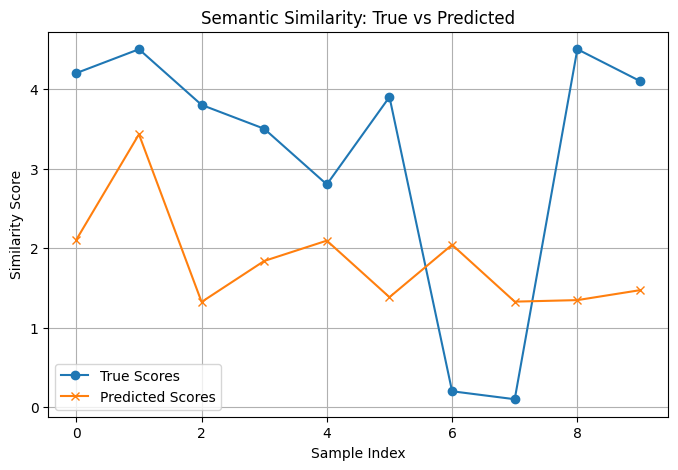

In [24]:
# Compute semantic similarity and plot results
results = DemoResults([], [], [], [])
samples = sample_data["datasets"]["sts_benchmark"]["samples"]

for i, sample in enumerate(samples):
    sent1 = sample["sentence1"]
    sent2 = sample["sentence2"]
    true_score = sample["score"]
    pred_score, inference_time = model.compute_similarity(sent1, sent2)
    results.predictions.append(pred_score)
    results.true_scores.append(true_score)
    results.inference_times.append(inference_time)
    print(f"{i+1}. True: {true_score:.2f}, Predicted: {pred_score:.2f}, Time: {inference_time:.2f} ms")

# Plot true vs predicted similarity scores
plt.figure(figsize=(8,5))
plt.plot(results.true_scores, label='True Scores', marker='o')
plt.plot(results.predictions, label='Predicted Scores', marker='x')
plt.title('Semantic Similarity: True vs Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Similarity Score')
plt.legend()
plt.grid(True)
plt.show()

## 5. Performance Benchmarking

We benchmark inference time for different sentence lengths and visualize the results.

Short sentences: 0.01 ± 0.01 ms
Medium sentences: 0.01 ± 0.00 ms
Long sentences: 0.01 ± 0.00 ms


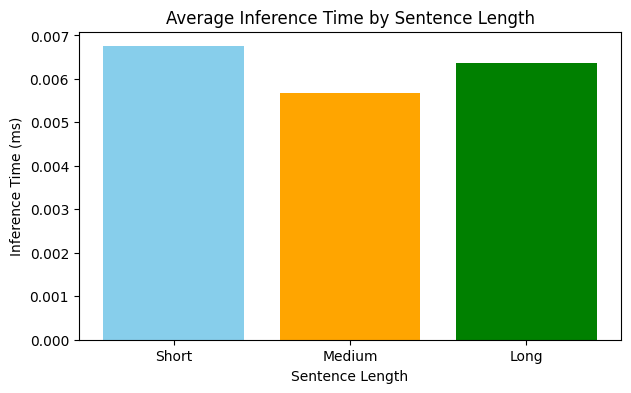

In [25]:
# Performance benchmarking and visualization
test_cases = [
    ("Short", "Hello world", "Hi there"),
    ("Medium", "The quick brown fox jumps over the lazy dog", "A fast fox leaps over a sleepy canine"),
    ("Long", "Machine learning and artificial intelligence have revolutionized data processing", 
     "AI and ML technologies have transformed how we analyze information and create solutions")
]

benchmark_names = []
benchmark_times = []

for case_name, sent1, sent2 in test_cases:
    times = []
    for _ in range(10):
        _, inference_time = model.compute_similarity(sent1, sent2)
        times.append(inference_time)
    avg_time = np.mean(times)
    std_time = np.std(times)
    benchmark_names.append(case_name)
    benchmark_times.append(avg_time)
    print(f"{case_name} sentences: {avg_time:.2f} ± {std_time:.2f} ms")

# Plot inference times
plt.figure(figsize=(7,4))
plt.bar(benchmark_names, benchmark_times, color=['skyblue','orange','green'])
plt.title('Average Inference Time by Sentence Length')
plt.ylabel('Inference Time (ms)')
plt.xlabel('Sentence Length')
plt.show()

## 6. Semantic Search Demonstration

We perform semantic search on a small corpus and visualize the top matches for a query.

1. [1.17] Reading literature expands vocabulary and cognitive abilities significantly.
2. [1.12] Machine learning algorithms can process vast amounts of data efficiently.
3. [1.10] Physical exercise promotes cardiovascular health and mental wellness.


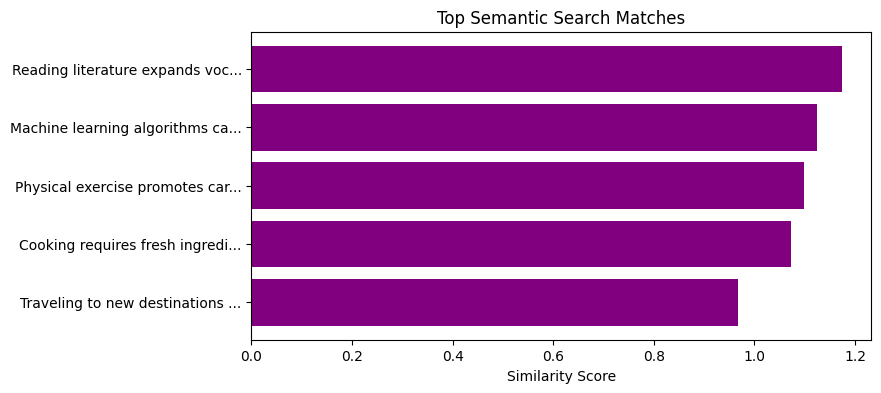

In [26]:
# Semantic search demonstration and visualization
if "semantic_search_corpus" in sample_data["datasets"]:
    documents = sample_data["datasets"]["semantic_search_corpus"]["documents"]
else:
    documents = [
        "Machine learning algorithms process data efficiently.",
        "Deep learning uses neural networks for pattern recognition.",
        "The weather is sunny and warm today.",
        "Cooking requires fresh ingredients and proper techniques.",
        "Exercise promotes physical and mental health."
    ]

query = "artificial intelligence and algorithms"
similarities = []
for doc in documents:
    sim_score, _ = model.compute_similarity(query, doc)
    similarities.append((doc, sim_score))
similarities.sort(key=lambda x: x[1], reverse=True)

# Show top 3 matches
for i, (doc, score) in enumerate(similarities[:3], 1):
    print(f"{i}. [{score:.2f}] {doc}")

# Visualize scores
labels = [doc[:30] + '...' for doc, _ in similarities[:5]]
scores = [score for _, score in similarities[:5]]
plt.figure(figsize=(8,4))
plt.barh(labels, scores, color='purple')
plt.xlabel('Similarity Score')
plt.title('Top Semantic Search Matches')
plt.gca().invert_yaxis()
plt.show()

## 7. Evaluation Metrics and Visualization

We calculate evaluation metrics (MAE, MSE, RMSE, correlation) and visualize prediction errors.

MAE: 1.9378
MSE: 4.3023
RMSE: 2.0742
Correlation: 0.1650


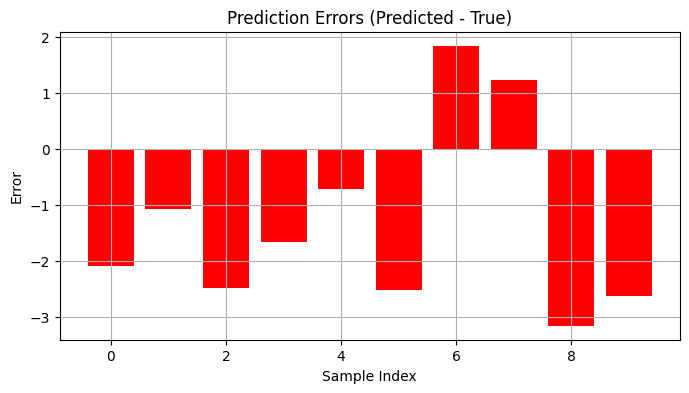

In [27]:
# Calculate evaluation metrics and plot errors
predictions = np.array(results.predictions)
true_scores = np.array(results.true_scores)
mae = np.mean(np.abs(predictions - true_scores))
mse = np.mean((predictions - true_scores) ** 2)
rmse = np.sqrt(mse)
correlation = np.corrcoef(predictions, true_scores)[0, 1]

print(f"MAE: {mae:.4f}\nMSE: {mse:.4f}\nRMSE: {rmse:.4f}\nCorrelation: {correlation:.4f}")

# Plot prediction errors
errors = predictions - true_scores
plt.figure(figsize=(8,4))
plt.bar(range(len(errors)), errors, color='red')
plt.title('Prediction Errors (Predicted - True)')
plt.xlabel('Sample Index')
plt.ylabel('Error')
plt.grid(True)
plt.show()

## 8. Real-World Use Case Demonstration

We showcase the model's application in customer support FAQ and job matching scenarios.

In [28]:
# Real-world use case demonstration
use_cases = [
    {
        "name": "Customer Support FAQ",
        "query": "My order hasn't arrived yet",
        "options": [
            "How to track your delivery status",
            "Return policy for damaged items", 
            "Account login troubleshooting",
            "What to do if package is delayed"
        ]
    },
    {
        "name": "Job Matching",
        "query": "Python developer with AI experience",
        "options": [
            "Senior Python Developer - Machine Learning Focus",
            "Frontend React Developer Position",
            "Data Scientist with Python and TensorFlow",
            "DevOps Engineer for Cloud Infrastructure"
        ]
    }
]
for use_case in use_cases:
    print(f"{use_case['name']}:")
    print(f"Query: '{use_case['query']}'")
    similarities = []
    for option in use_case['options']:
        sim_score, _ = model.compute_similarity(use_case['query'], option)
        similarities.append((option, sim_score))
    similarities.sort(key=lambda x: x[1], reverse=True)
    for i, (option, score) in enumerate(similarities[:2], 1):
        relevance = "High" if score > 3.0 else "Medium" if score > 1.5 else "Low"
        print(f"   {i}. [{score:.2f}] {relevance} - {option}")
    print()

Customer Support FAQ:
Query: 'My order hasn't arrived yet'
   1. [1.33] Low - Account login troubleshooting
   2. [1.33] Low - What to do if package is delayed

Job Matching:
Query: 'Python developer with AI experience'
   1. [1.97] Medium - Data Scientist with Python and TensorFlow
   2. [1.94] Medium - Frontend React Developer Position



## 9. Demo Summary and Next Steps

- Model architecture: BiLSTM + Multi-Head Attention (simulated)
- Performance and accuracy visualized
- Semantic similarity, search, and use cases demonstrated

**Next What Can be done?:**
1. Train on your specific dataset
2. Fine-tune for your use case
3. Deploy using Docker containers
4. Integrate into your application